In [96]:
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [97]:
if "src" not in os.listdir():
    os.chdir("./../")
    print(f"Working on {os.getcwd()} directory")

if "src" not in sys.path:
    sys.path.append("src")

In [98]:
from utils import files

In [99]:
FILE_CONFIG = "./configs/files.yaml"

configs = files.load_yaml(FILE_CONFIG)

filenames = os.listdir(configs["VOTERS_DATA_PATH"])
most_recent_voting_path = os.path.join(configs["VOTERS_DATA_PATH"], sorted(filenames)[-1])

df_votes = pd.read_csv(most_recent_voting_path)
df_voters = df_votes.query("is_judge == False")
df_judges = df_votes.query("is_judge == True")

df_votes.tail()

,timestamp,category_id,voter_id,predicted_winner_id,explanation,is_judge
307,2026-03-09 10:36:54.767063-03:00,writing_adapted_screenplay,judge_o3_user_prompt_repetitions_2,1y6q98,Hamnet receives unanimous or near-unanimous ba...,True
308,2026-03-09 10:36:54.767063-03:00,writing_original_screenplay,judge_o3_user_prompt_repetitions_2,opi1s4,Sentimental Value edges Marty Supreme in votes...,True
309,2026-03-09 10:36:54.767063-03:00,sound,judge_o3_user_prompt_repetitions_2,43bp0u,F1 dominates the ballots; its immersive engine...,True
310,2026-03-09 10:36:54.767063-03:00,costume_design,judge_o3_user_prompt_repetitions_2,yuspko,Hamnet gains more votes (4-to-3) for historica...,True
311,2026-03-09 10:36:54.767063-03:00,cinematography,judge_o3_user_prompt_repetitions_2,p5jizs,Frankenstein secures the majority; Dan Laustse...,True


In [100]:
categories = files.load_yaml(configs["CATEGORIES_CONFIG_PATH"])
df_categories = (
    pd.DataFrame.from_records(categories).T
    .explode("nominees")
    .reset_index(drop=False)
    .rename({"index": "category_id", "name": "category_name"}, axis=1)
)
df_categories["nominee_id"] = df_categories["nominees"].apply(lambda x: x["id"])
df_categories["nominee_name"] = df_categories["nominees"].apply(lambda x: x["name"])
# categories
df_categories

,category_id,category_name,description,nominees,nominee_id,nominee_name
0,actor_in_a_leading_role,Actor in a Leading Role,Best performance by an actor in a leading role.,"{'id': 'mwdue1', 'name': 'Timothée Chalamet', ...",mwdue1,Timothée Chalamet
1,actor_in_a_leading_role,Actor in a Leading Role,Best performance by an actor in a leading role.,"{'id': 'ec0ne0', 'name': 'Leonardo DiCaprio', ...",ec0ne0,Leonardo DiCaprio
2,actor_in_a_leading_role,Actor in a Leading Role,Best performance by an actor in a leading role.,"{'id': 'kflgyk', 'name': 'Ethan Hawke', 'movie...",kflgyk,Ethan Hawke
3,actor_in_a_leading_role,Actor in a Leading Role,Best performance by an actor in a leading role.,"{'id': 'n6zr8m', 'name': 'Michael B. Jordan', ...",n6zr8m,Michael B. Jordan
4,actor_in_a_leading_role,Actor in a Leading Role,Best performance by an actor in a leading role.,"{'id': '4tvhm0', 'name': 'Wagner Moura', 'movi...",4tvhm0,Wagner Moura
...,...,...,...,...,...,...
115,writing_original_screenplay,Writing (Original Screenplay),Best original screenplay written directly for ...,"{'id': 'snqpex', 'name': 'Blue Moon', 'movie':...",snqpex,Blue Moon
116,writing_original_screenplay,Writing (Original Screenplay),Best original screenplay written directly for ...,"{'id': 'd3654y', 'name': 'It Was Just an Accid...",d3654y,It Was Just an Accident
117,writing_original_screenplay,Writing (Original Screenplay),Best original screenplay written directly for ...,"{'id': 'o12n2f', 'name': 'Marty Supreme', 'mov...",o12n2f,Marty Supreme
118,writing_original_screenplay,Writing (Original Screenplay),Best original screenplay written directly for ...,"{'id': 'opi1s4', 'name': 'Sentimental Value', ...",opi1s4,Sentimental Value


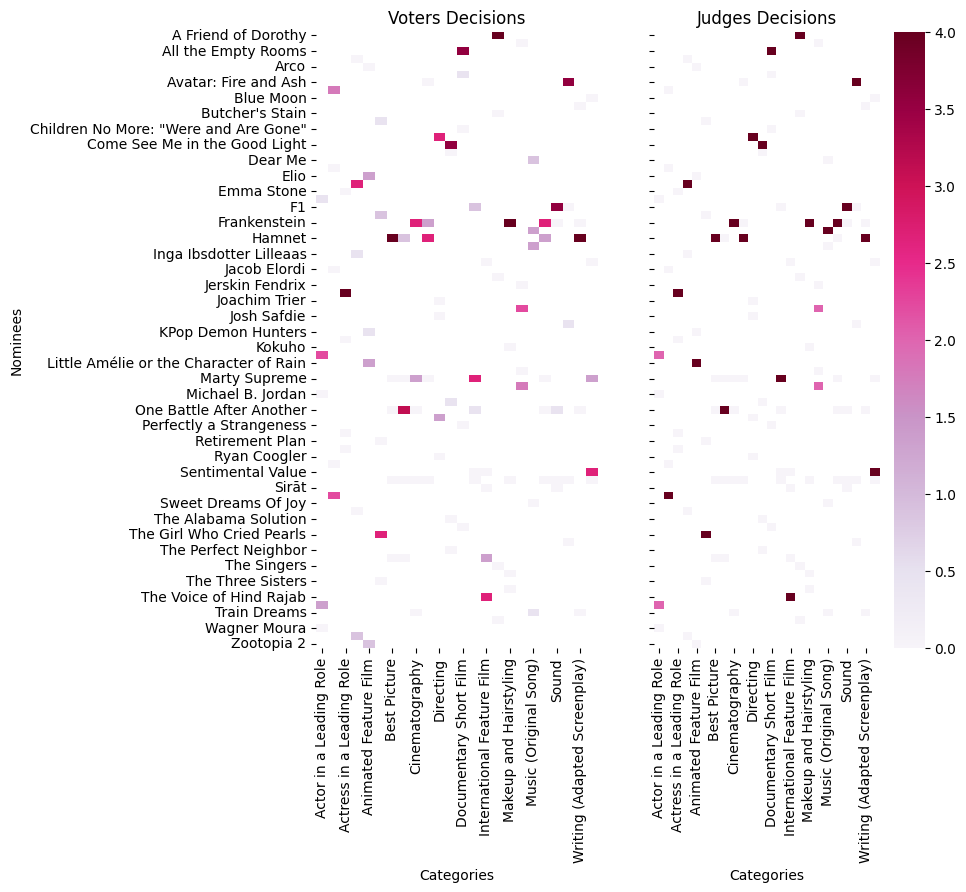

In [101]:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 8), sharey=True)

for i, df_evaluator in enumerate([df_voters, df_judges]):
    ax = axes[i]
    df_plot = (
        df_categories
        .merge(df_evaluator.rename({"predicted_winner_id": "nominee_id"}, axis=1), on=["category_id", "nominee_id"], how="left")
        .groupby(["category_name", "nominee_name"])
        .agg({"voter_id": "count"})
        .assign(votes_pct = lambda x: x.voter_id / df_voters["voter_id"].nunique())
        .assign(votes_count = lambda x: x.voter_id)
        .reset_index()
        .pivot(index="nominee_name", columns="category_name", values="votes_count")
    )

    sns.heatmap(data=df_plot, ax=ax, vmin=0.0, annot=False, fmt=".02f", cmap="PuRd", cbar=False if i == 0 else True)

    ax.set_title(f"{'Voters' if i == 0 else 'Judges'} Decisions")
    ax.set_ylabel("Nominees" if i == 0 else "")
    ax.set_xlabel("Categories")


# df_plot